<a href="https://colab.research.google.com/github/GilTaeho/FACE_RECOGNITION-PROJECT/blob/main/cnn_%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5_(%ED%91%9C%EC%A0%95_%EB%B6%84%EB%A5%98).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 필요한 파일 다운로드 및 셋업

In [ ]:
#캐글 파일 다운로드
import os
os.environ['KAGGLE_USERNAME'] = "jiyunishere"
os.environ['KAGGLE_KEY'] = "7e690b22a3d4e2b8059cc2e961b180f3"
!kaggle datasets download -d msambare/fer2013

 98% 59.0M/60.3M [00:00<00:00, 224MB/s]
100% 60.3M/60.3M [00:00<00:00, 203MB/s]


In [ ]:
#ZIP파일 임포트
from zipfile import ZipFile
file_name = "/content/fer2013.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('done')

done


In [ ]:
#필요한 셋업
import os, re, glob
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from keras.models import Sequential
from keras.layers import Dropout, Activation, Dense
from keras.layers import Flatten, Convolution2D, MaxPooling2D
from keras.models import load_model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import requests
from PIL import Image
from io import BytesIO
from IPython.display import Image
from urllib.request import urlopen
from PIL import Image
import requests
from io import BytesIO
from PIL import Image
from keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import numpy as np

# 2. 데이터 분류

In [ ]:
#폴더에서 train데이터 불러오기 및 카테고리 분류
groups_folder_path = '/content/train/'
categories = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

num_classes = len(categories)

print(num_classes)

7


In [ ]:
#train 데이터셋, test 데이터셋, validation 데이터셋 분류하기
image_w = 28
image_h = 28

X = []
Y = []

for idex, categorie in enumerate(categories):
    label = [0 for i in range(num_classes)]
    label[idex] = 1
    image_dir = groups_folder_path + categorie + '/'

    for top, dir, f in os.walk(image_dir):
      for filename in f:
          img = cv2.imread(image_dir+filename)
          img = cv2.resize(img, None, fx=image_w/img.shape[1], fy=image_h/img.shape[0])
          X.append(img/256)
          Y.append(label)

X = np.array(X)
Y = np.array(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2)

In [ ]:
print(len(X_train))
print(len(Y_train))

print(len(X_val))
print(len(Y_val))

print(len(X_test))
print(len(Y_test))


18373
18373
4594
4594
5742
5742


(28, 28, 3)


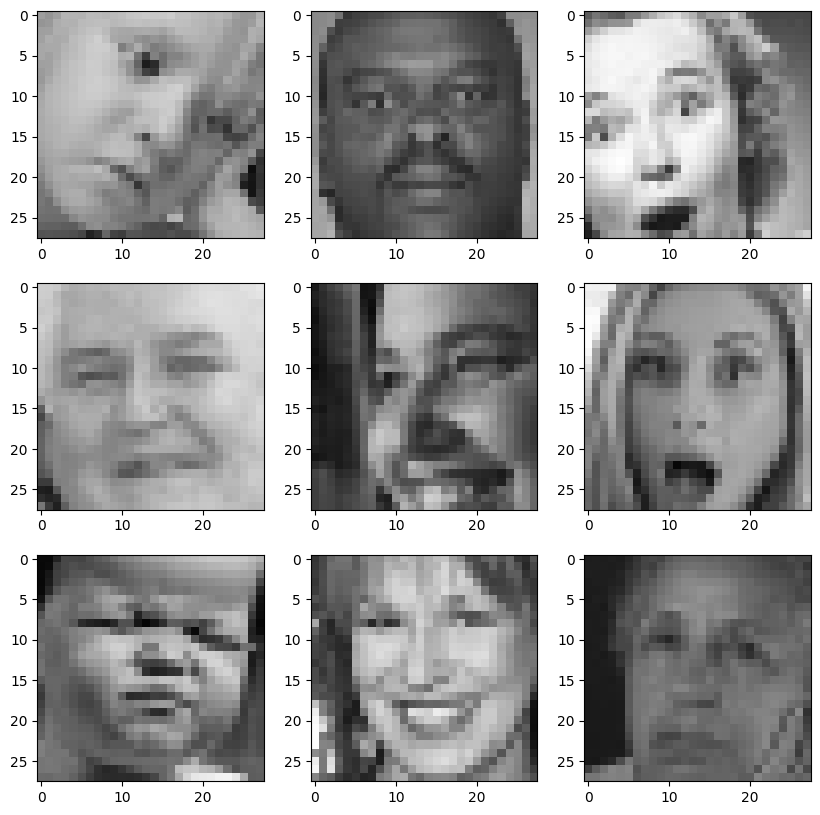

In [ ]:
#사진 확인하기
print(X_train[0].shape)

fig = plt.figure(figsize = (10, 10))
for i in range(9):
  fig.add_subplot(3, 3, i+1)
  plt.imshow(X_train[i])

plt.show()

# 3. CNN 모델 설계


In [ ]:
# CNN 모델 설계
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=3, padding='valid', activation='relu', input_shape=(28, 28, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(7, activation='softmax')
])

# 모델 컴파일 및 fit시키기
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

history=model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, callbacks=[early_stopping])

model.save('Gersang.h5')


Epoch 1/20
575/575 [==============================] - 9s 7ms/step - loss: 1.8050 - accuracy: 0.2501 - val_loss: 1.7645 - val_accuracy: 0.2658
Epoch 2/20
575/575 [==============================] - 4s 6ms/step - loss: 1.7597 - accuracy: 0.2710 - val_loss: 1.7149 - val_accuracy: 0.3119
Epoch 3/20
575/575 [==============================] - 3s 5ms/step - loss: 1.6811 - accuracy: 0.3285 - val_loss: 1.6086 - val_accuracy: 0.3759
Epoch 4/20
575/575 [==============================] - 3s 5ms/step - loss: 1.6056 - accuracy: 0.3730 - val_loss: 1.5537 - val_accuracy: 0.4040
Epoch 5/20
575/575 [==============================] - 3s 6ms/step - loss: 1.5658 - accuracy: 0.3931 - val_loss: 1.5235 - val_accuracy: 0.4116
Epoch 6/20
575/575 [==============================] - 3s 5ms/step - loss: 1.5263 - accuracy: 0.4156 - val_loss: 1.4930 - val_accuracy: 0.4247
Epoch 7/20
575/575 [==============================] - 3s 5ms/step - loss: 1.4968 - accuracy: 0.4269 - val_loss: 1.4870 - val_accuracy: 0.4343
Epoch 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# 4. 손실함수와 정확도를 그래프로 확인

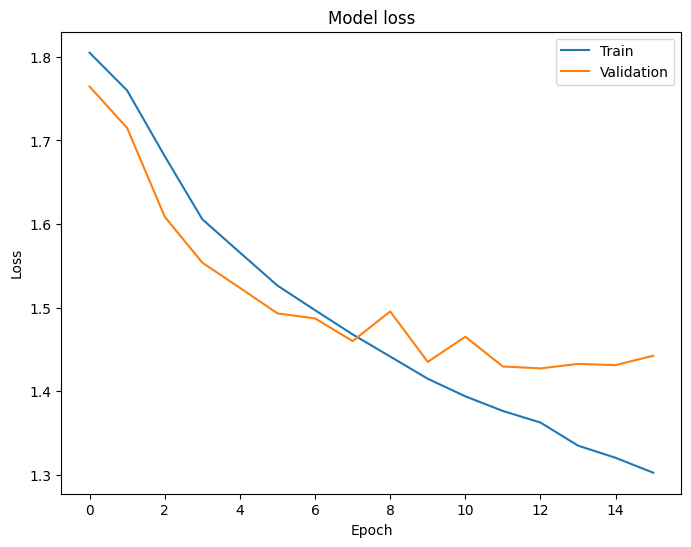

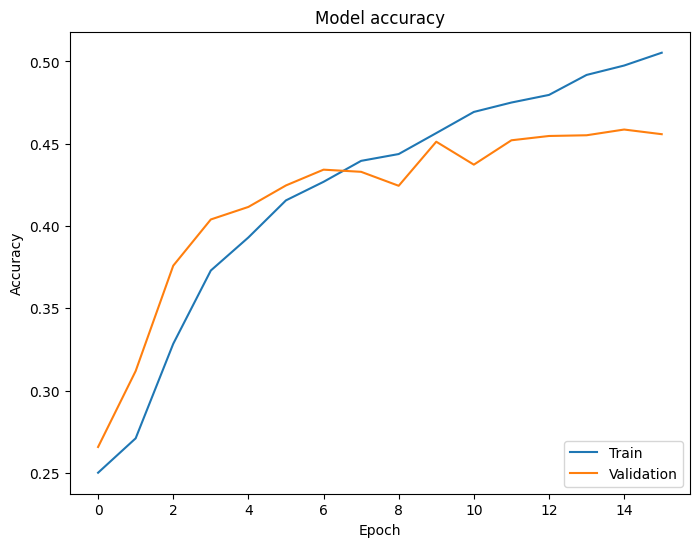

In [ ]:
# 손실함수 그래프
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# 정확도 그래프
fig, ax = plt.subplots(figsize=(8,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

# 5. 모델 평가

In [ ]:
#모델 평가하기
model = load_model('Gersang.h5')

model.evaluate(X_test,Y_test)[1]

180/180 [==============================] - 1s 4ms/step - loss: 1.4491 - accuracy: 0.4565


0.4564611613750458

# 6. 결과 테스트
**코드 두번째 줄의 URL 변수에 사진 주소 입력하면 결과 확인 가능**          
ex)url='사진 주소'           


In [ ]:
# URL 입력하기
url = 'https://st3.depositphotos.com/4218696/33152/i/450/depositphotos_331521452-stock-photo-surprised-black-man-touching-face.jpg'
# 이미지 다운로드
response = requests.get(url)
i = Image.open(BytesIO(response.content))

# 이미지 크기 조절
image = i.resize((224, 224))
image = image.resize((28, 28))

# 이미지를 넘파이 배열로 변환 및 정규화
img_array = img_to_array(image, data_format='channels_last') / 255.0

# 이미지를 batch_size 1로 변환
preprocessed_img = np.expand_dims(img_array, axis=0)

# 모델 로드하기
model = load_model('Gersang.h5')

# 예측하기
predicted_probabilities = model.predict(preprocessed_img)

# 예측 결과를 categories 배열에서의 원소번호로 변환
predicted_category = np.argmax(predicted_probabilities)
print(predicted_probabilities)
categories = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

# 설정한 확률 임계치 이상인 경우에만 출력
confidence_threshold = 0.5
if predicted_probabilities[0, predicted_category] >= confidence_threshold:
    #결과값이 신뢰할 만한 경우의 결과 출력
    print(categories[predicted_category])
else:
  #결과값이 신뢰하기 어려운 경우의 결과 출력
    print("Not confident about prediction")


1/1 [==============================] - 0s 106ms/step
[[0.05044714 0.00528587 0.1924945  0.12772244 0.12373129 0.36641043
  0.1339083 ]]
Not confident about prediction
